In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
# Load and preprocess MNIST
(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))
#Generate noisy versions
noise_factor_low = 0.1
noise_factor_high = 0.5
x_train_noisy_low = x_train + noise_factor_low * np.random.normal(loc=0.0, scale=1.0, size=x_train.
shape)
x_train_noisy_high = x_train + noise_factor_high * np.random.normal(loc=0.0, scale=1.0, size=x_train
.shape)
x_test_noisy_low = x_test + noise_factor_low * np.random.normal(loc=0.0, scale=1.0, size=x_test.
shape)
x_test_noisy_high = x_test + noise_factor_high * np.random.normal(loc=0.0, scale=1.0, size=x_test.
shape)
# Clip pixel values to [0, 1]
x_train_noisy_low = np.clip(x_train_noisy_low, 0., 1.)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


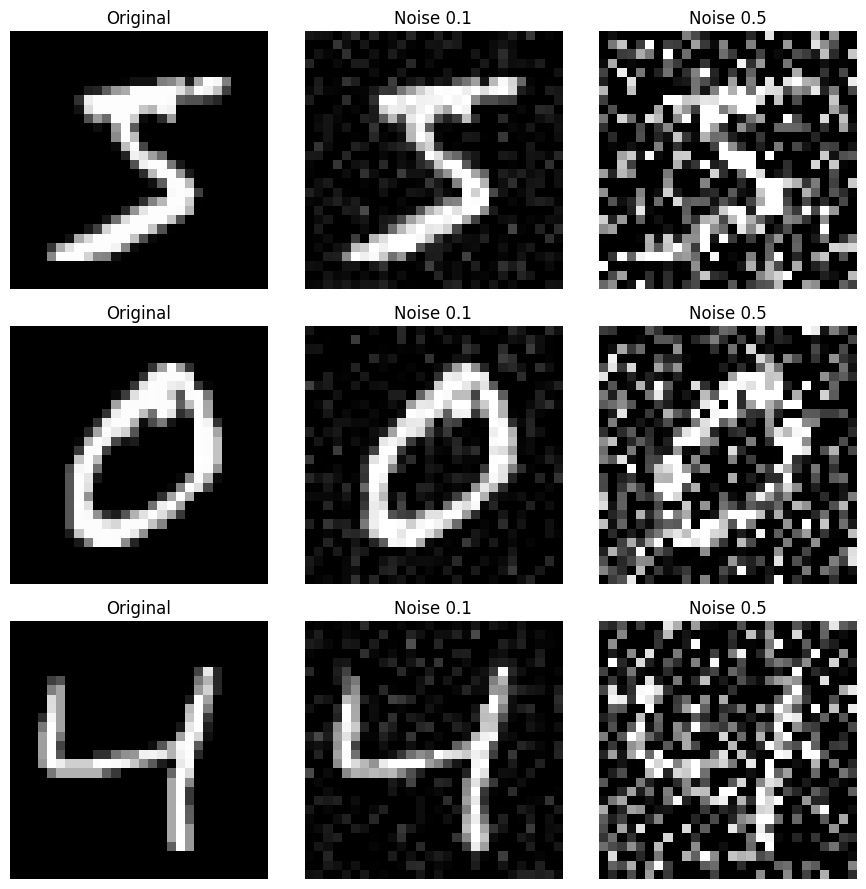

In [3]:
x_test_noisy_low = np.clip(x_test_noisy_low, 0., 1.)
x_train_noisy_high = np.clip(x_train_noisy_high, 0., 1.)
x_test_noisy_high = np.clip(x_test_noisy_high, 0., 1.)
#Visualize in a 3 x 3 grid
n = 3 # number of images to show
plt.figure(figsize=(9, 9))
for i in range(n):
    # Original image
    ax = plt.subplot(n, 3, i * 3 + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')
    # Low noise image
    ax = plt.subplot(n, 3, i * 3 + 2)
    plt.imshow(x_train_noisy_low[i].reshape(28, 28), cmap='gray')
    plt.title("Noise 0.1")
    plt.axis('off')
    # High noise image
    ax = plt.subplot(n, 3, i * 3 + 3)
    plt.imshow(x_train_noisy_high[i].reshape(28, 28), cmap='gray')
    plt.title("Noise 0.5")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [4]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D

def build_encoder(input_shape=(28, 28, 1)):
    """
    Builds the encoder part of the convolutional autoencoder.
    Parameters:
        input_shape (tuple): Shape of the input image. Default is (28, 28, 1) for MNIST.
    Returns:
        input_img (Keras Input): Input layer of the model.
        encoded (Keras Tensor): Encoded representation after convolution and pooling.
    """
    input_img = Input(shape=input_shape, name="input")
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
    x = MaxPooling2D((2, 2), padding='same')(x)
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    encoded = MaxPooling2D((2, 2), padding='same', name="encoded")(x)
    return input_img, encoded

In [5]:
from tensorflow.keras.layers import UpSampling2D # Add this import

def build_decoder(encoded_input):
    """
    Builds the decoder part of the convolutional autoencoder.
    Parameters:
        encoded_input (Keras Tensor): The output from the encoder.
    Returns:
        decoded (Keras Tensor): The reconstructed output after upsampling and
        convolution.
    """
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(encoded_input)
    x = UpSampling2D((2, 2))(x)
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = UpSampling2D((2, 2))(x)
    decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same', name="decoded")(x)
    return decoded

In [6]:
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

def build_autoencoder():
    """
    Constructs and compiles the full convolutional autoencoder by connecting encoder and
    decoder.
    Returns:
        autoencoder (Keras Model): Compiled autoencoder model.
    """
    input_img, encoded_output = build_encoder()
    decoded_output = build_decoder(encoded_output)
    autoencoder = Model(inputs=input_img, outputs=decoded_output, name="autoencoder")
    autoencoder.compile(optimizer=Adam(), loss='binary_crossentropy')
    return autoencoder

In [ ]:
autoencoder = build_autoencoder()
autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoded (MaxPooling2D)          │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoded (Conv2D)                │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Build the autoencoder from previous steps
autoencoder = build_autoencoder()
# Train with noisy input and clean target
history = autoencoder.fit(
x_train_noisy_high, x_train,
epochs=10,
batch_size=128,
shuffle=True,
validation_data=(x_test_noisy_high, x_test)
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 120s 252ms/step - loss: 0.1578 - val_loss: 0.1129
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 113s 241ms/step - loss: 0.1096 - val_loss: 0.1055
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 139s 234ms/step - loss: 0.1043 - val_loss: 0.1019
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 101s 216ms/step - loss: 0.1016 - val_loss: 0.1007
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 142s 215ms/step - loss: 0.1000 - val_loss: 0.0984
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 107s 228ms/step - loss: 0.0988 - val_loss: 0.0975
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 116s 247ms/step - loss: 0.0978 - val_loss: 0.0968
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 114s 242ms/step - loss: 0.0971 - val_loss: 0.0961
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 113s 241ms/step - loss: 0.0965 - val_loss: 0.0969
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 111s 236ms/step - loss: 0.0960 - val_loss: 0.0952


313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step


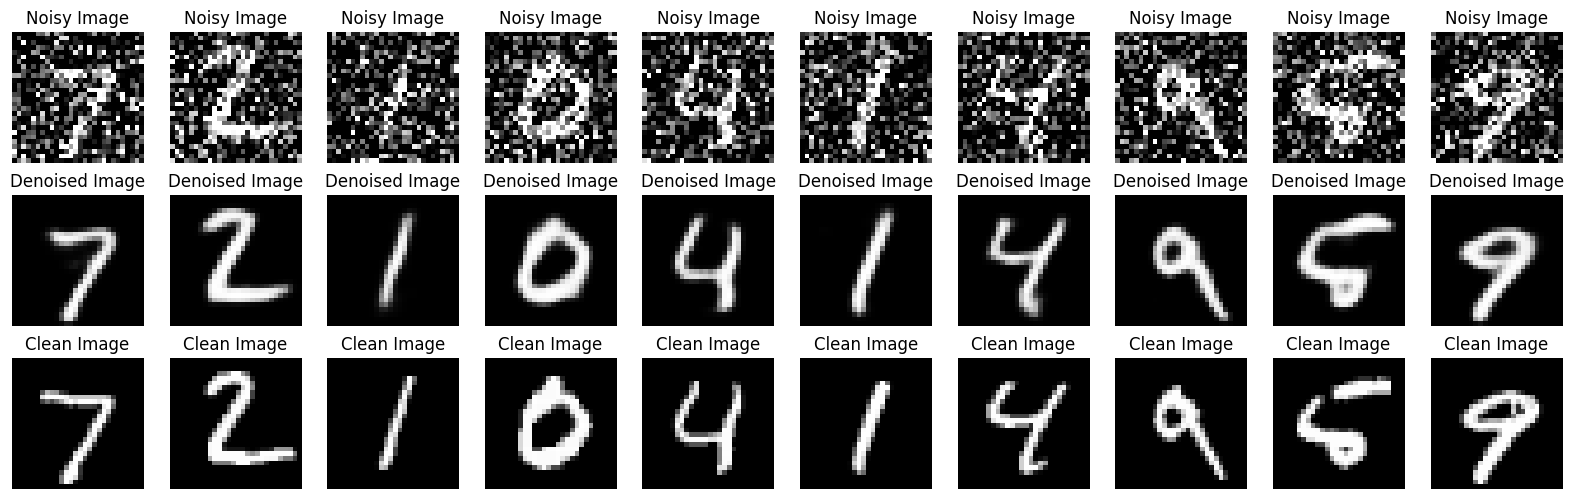

In [9]:
import matplotlib.pyplot as plt

# Predict the denoised images from noisy test images
denoised_images = autoencoder.predict(x_test_noisy_high)

# Function to display images
def plot_images(noisy_images, denoised_images, clean_images, n=10):
    plt.figure(figsize=(20, 6))
    for i in range(n):
        # Plot noisy images
        plt.subplot(3, n, i + 1)
        plt.imshow(noisy_images[i].reshape(28, 28), cmap='gray')
        plt.title("Noisy Image")
        plt.axis('off')
        # Plot denoised images
        plt.subplot(3, n, i + 1 + n)
        plt.imshow(denoised_images[i].reshape(28, 28), cmap='gray')
        plt.title("Denoised Image")
        plt.axis('off')
        # Plot clean images
        plt.subplot(3, n, i + 1 + 2 * n)
        plt.imshow(clean_images[i].reshape(28, 28), cmap='gray')
        plt.title("Clean Image")
        plt.axis('off')
    plt.show()

# Display the first 10 images
plot_images(x_test_noisy_high, denoised_images, x_test)

4 Exercise: Build a Denoising Convolutional Autoencoder

In [49]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow : {tf.__version__}")
print(f"GPU devices: {tf.config.list_physical_devices('GPU')}")

TensorFlow : 2.19.0
GPU devices: []


In [50]:
from google.colab import drive
drive.mount('/content/drive')

ZIP_PATH    = '/content/drive/MyDrive/AI ML/Data/Copy of devnagari digit.zip'
EXTRACT_DIR = '/content/devnagari'

if not os.path.exists(EXTRACT_DIR):
    with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
        zf.extractall(EXTRACT_DIR)
    print("Extraction complete.")
else:
    print("Already extracted.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Already extracted.


In [51]:
print("=== Directory tree (max depth 4) ===")
for root, dirs, files in os.walk(EXTRACT_DIR):
    depth = root.replace(EXTRACT_DIR, '').count(os.sep)
    if depth > 4:
        continue
    indent = '  ' * depth
    print(f"{indent}{os.path.basename(root)}/")
    for f in files[:2]:
        print(f"{'  ' * (depth+1)}{f}")
    if len(files) > 2:
        print(f"{'  ' * (depth+1)}... ({len(files)} files total)")

=== Directory tree (max depth 4) ===
devnagari/
  DevanagariHandwrittenDigitDataset/
    Train/
      digit_4/
        40886.png
        41112.png
        ... (1700 files total)
      digit_1/
        29208.png
        6906.png
        ... (1700 files total)
      digit_6/
        19023.png
        99173.png
        ... (1700 files total)
      digit_7/
        30375.png
        41951.png
        ... (1700 files total)
      digit_3/
        49616.png
        5129.png
        ... (1700 files total)
      digit_5/
        13541.png
        77827.png
        ... (1700 files total)
      digit_9/
        68668.png
        90140.png
        ... (1700 files total)
      digit_2/
        12559.png
        13476.png
        ... (1700 files total)
      digit_0/
        18521.png
        89396.png
        ... (1700 files total)
      digit_8/
        50005.png
        68293.png
        ... (1700 files total)
    Test/
      digit_4/
        77506.png
        41116.png
        ... (300 files to

In [52]:
IMG_SIZE = (32, 32)
images   = []
labels   = []
label_map = {}
label_counter = 0

def find_image_dirs(base):
    """Return every directory that directly contains image files."""
    result = []
    for root, dirs, files in os.walk(base):
        imgs = [f for f in files if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        if imgs:
            result.append(root)
    return result

image_dirs = find_image_dirs(EXTRACT_DIR)
print(f"Image-containing directories found: {len(image_dirs)}")
for d in image_dirs[:10]:
    print(f"  {d}")

for img_dir in image_dirs:
    class_name = os.path.basename(img_dir)
    if class_name not in label_map:
        label_map[class_name] = label_counter
        label_counter += 1
    label = label_map[class_name]

    for fname in sorted(os.listdir(img_dir)):
        if not fname.lower().endswith(('.png', '.jpg', '.jpeg')):
            continue
        img_path = os.path.join(img_dir, fname)
        img = Image.open(img_path).convert('L')   # grayscale
        img = img.resize(IMG_SIZE)
        images.append(np.array(img, dtype='float32'))
        labels.append(label)

images = np.array(images, dtype='float32')
labels = np.array(labels)

print(f"\nTotal images loaded : {images.shape[0]}")
print(f"Image shape         : {images.shape[1:]}")
print(f"Number of classes   : {len(label_map)}")
print(f"Class names         : {list(label_map.keys())}")

Image-containing directories found: 20
  /content/devnagari/DevanagariHandwrittenDigitDataset/Train/digit_4
  /content/devnagari/DevanagariHandwrittenDigitDataset/Train/digit_1
  /content/devnagari/DevanagariHandwrittenDigitDataset/Train/digit_6
  /content/devnagari/DevanagariHandwrittenDigitDataset/Train/digit_7
  /content/devnagari/DevanagariHandwrittenDigitDataset/Train/digit_3
  /content/devnagari/DevanagariHandwrittenDigitDataset/Train/digit_5
  /content/devnagari/DevanagariHandwrittenDigitDataset/Train/digit_9
  /content/devnagari/DevanagariHandwrittenDigitDataset/Train/digit_2
  /content/devnagari/DevanagariHandwrittenDigitDataset/Train/digit_0
  /content/devnagari/DevanagariHandwrittenDigitDataset/Train/digit_8

Total images loaded : 20000
Image shape         : (32, 32)
Number of classes   : 10
Class names         : ['digit_4', 'digit_1', 'digit_6', 'digit_7', 'digit_3', 'digit_5', 'digit_9', 'digit_2', 'digit_0', 'digit_8']


In [53]:
# Normalise to [0, 1]
images = images / 255.0

# (N, 32, 32) --> (N, 32, 32, 1)
images = images[..., np.newaxis]

print(f"Dataset shape : {images.shape}")
print(f"Pixel min     : {images.min():.4f}")
print(f"Pixel max     : {images.max():.4f}")

Dataset shape : (20000, 32, 32, 1)
Pixel min     : 0.0000
Pixel max     : 1.0000


In [54]:
x_train, x_val = train_test_split(images, test_size=0.15, random_state=42)

print(f"Training samples   : {x_train.shape[0]}")
print(f"Validation samples : {x_val.shape[0]}")

Training samples   : 17000
Validation samples : 3000


In [55]:
def add_gaussian_noise(imgs, noise_factor=0.35):
    noisy = imgs + noise_factor * np.random.randn(*imgs.shape)
    return np.clip(noisy, 0., 1.).astype('float32')

def add_salt_pepper_noise(imgs, prob=0.05):
    noisy = imgs.copy()
    salt   = np.random.rand(*imgs.shape) < (prob / 2)
    pepper = np.random.rand(*imgs.shape) < (prob / 2)
    noisy[salt]   = 1.0
    noisy[pepper] = 0.0
    return noisy.astype('float32')

NOISE_FACTOR = 0.35

x_train_noisy = add_gaussian_noise(x_train, NOISE_FACTOR)
x_val_noisy   = add_gaussian_noise(x_val,   NOISE_FACTOR)

print(f"Noisy train shape : {x_train_noisy.shape}")
print(f"Noisy val shape   : {x_val_noisy.shape}")

Noisy train shape : (17000, 32, 32, 1)
Noisy val shape   : (3000, 32, 32, 1)


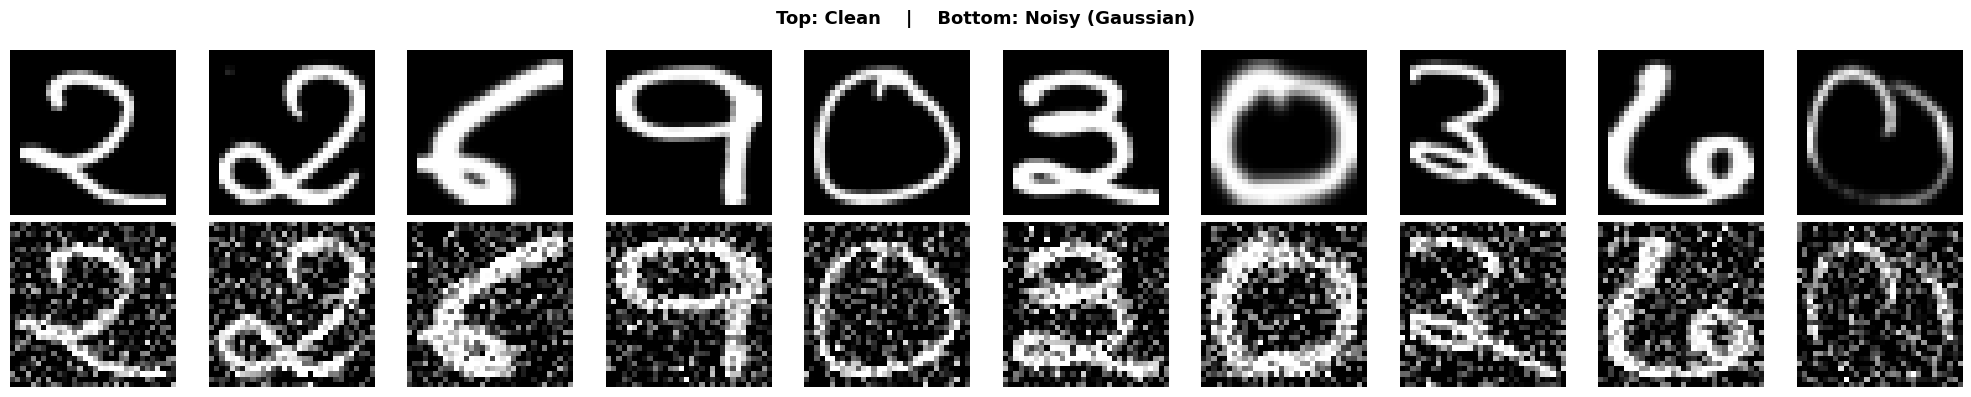

In [56]:
n = 10
fig, axes = plt.subplots(2, n, figsize=(20, 4))
fig.suptitle('Top: Clean    |    Bottom: Noisy (Gaussian)', fontsize=13, fontweight='bold')

for i in range(n):
    axes[0, i].imshow(x_train[i].squeeze(), cmap='gray', vmin=0, vmax=1)
    axes[0, i].axis('off')
    axes[1, i].imshow(x_train_noisy[i].squeeze(), cmap='gray', vmin=0, vmax=1)
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

In [58]:
def build_autoencoder(input_shape=(32, 32, 1)):
    inputs = layers.Input(shape=input_shape, name='input')

    x = layers.Conv2D(32,  (3,3), activation='relu', padding='same', name='enc_conv1')(inputs)
    x = layers.MaxPooling2D((2,2), padding='same', name='pool1')(x)          # 16 x 16

    x = layers.Conv2D(64,  (3,3), activation='relu', padding='same', name='enc_conv2')(x)
    x = layers.MaxPooling2D((2,2), padding='same', name='pool2')(x)          # 8 x 8

    x = layers.Conv2D(128, (3,3), activation='relu', padding='same', name='enc_conv3')(x)
    x = layers.MaxPooling2D((2,2), padding='same', name='pool3')(x)          # 4 x 4

    x = layers.Conv2D(256, (3,3), activation='relu', padding='same', name='enc_conv4')(x)
    encoded = layers.MaxPooling2D((2,2), padding='same', name='bottleneck')(x)  # 2 x 2


    x = layers.Conv2D(256, (3,3), activation='relu', padding='same', name='dec_conv1')(encoded)
    x = layers.UpSampling2D((2,2), name='up1')(x)                            # 4 x 4

    x = layers.Conv2D(128, (3,3), activation='relu', padding='same', name='dec_conv2')(x)
    x = layers.UpSampling2D((2,2), name='up2')(x)                            # 8 x 8

    x = layers.Conv2D(64,  (3,3), activation='relu', padding='same', name='dec_conv3')(x)
    x = layers.UpSampling2D((2,2), name='up3')(x)                            # 16 x 16

    x = layers.Conv2D(32,  (3,3), activation='relu', padding='same', name='dec_conv4')(x)
    x = layers.UpSampling2D((2,2), name='up4')(x)                            # 32 x 32

    decoded = layers.Conv2D(1, (3,3), activation='sigmoid', padding='same', name='output')(x)

    return Model(inputs, decoded, name='Denoising_CAE')

autoencoder = build_autoencoder()
autoencoder.summary()

Model: "Denoising_CAE"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv1 (Conv2D)              │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv2 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv3 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv4 (Conv2D)              │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (MaxPooling2D)       │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_conv1 (Conv2D)              │ (None, 2, 2, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up1 (UpSampling2D)              │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_conv2 (Conv2D)              │ (None, 4, 4, 128)      │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up2 (UpSampling2D)              │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_conv3 (Conv2D)              │ (None, 8, 8, 64)       │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up3 (UpSampling2D)              │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_conv4 (Conv2D)              │ (None, 16, 16, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up4 (UpSampling2D)              │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Conv2D)                 │ (None, 32, 32, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,365,505 (5.21 MB)

 Trainable params: 1,365,505 (5.21 MB)

 Non-trainable params: 0 (0.00 B)

In [59]:
autoencoder.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['mae']
)

print("Model compiled successfully.")
print(f"Total parameters: {autoencoder.count_params():,}")

Model compiled successfully.
Total parameters: 1,365,505


In [60]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=8,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=4, min_lr=1e-6, verbose=1)
]

history = autoencoder.fit(
    x_train_noisy, x_train,           # noisy input --> clean target
    epochs=50,
    batch_size=64,
    shuffle=True,
    validation_data=(x_val_noisy, x_val),
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
266/266 ━━━━━━━━━━━━━━━━━━━━ 138s 506ms/step - loss: 0.3859 - mae: 0.2201 - val_loss: 0.2568 - val_mae: 0.1279 - learning_rate: 0.0010
Epoch 2/50
266/266 ━━━━━━━━━━━━━━━━━━━━ 124s 468ms/step - loss: 0.2160 - mae: 0.0985 - val_loss: 0.1939 - val_mae: 0.0831 - learning_rate: 0.0010
Epoch 3/50
266/266 ━━━━━━━━━━━━━━━━━━━━ 122s 457ms/step - loss: 0.1809 - mae: 0.0732 - val_loss: 0.1752 - val_mae: 0.0685 - learning_rate: 0.0010
Epoch 4/50
266/266 ━━━━━━━━━━━━━━━━━━━━ 121s 453ms/step - loss: 0.1673 - mae: 0.0634 - val_loss: 0.1640 - val_mae: 0.0611 - learning_rate: 0.0010
Epoch 5/50
266/266 ━━━━━━━━━━━━━━━━━━━━ 124s 467ms/step - loss: 0.1599 - mae: 0.0581 - val_loss: 0.1579 - val_mae: 0.0568 - learning_rate: 0.0010
Epoch 6/50
266/266 ━━━━━━━━━━━━━━━━━━━━ 131s 494ms/step - loss: 0.1547 - mae: 0.0542 - val_loss: 0.1540 - val_mae: 0.0536 - learning_rate: 0.0010
Epoch 7/50
266/266 ━━━━━━━━━━━━━━━━━━━━ 127s 479ms/step - loss: 0.1506 - mae: 0.0512 - val_loss: 0.1506 - val_mae: 0.0509 - 

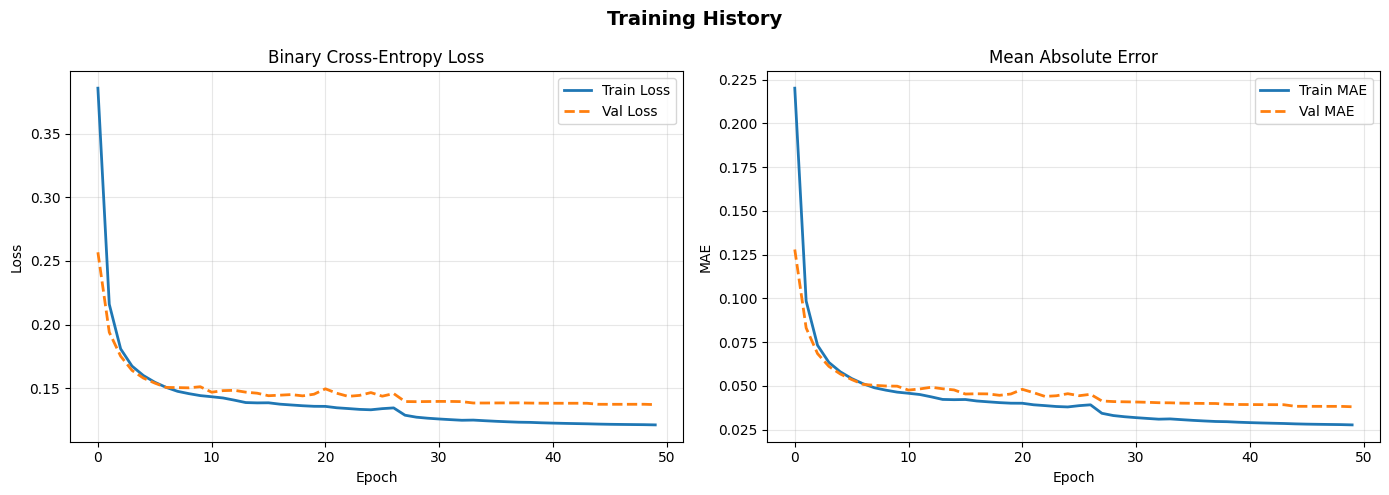

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training History', fontsize=14, fontweight='bold')

axes[0].plot(history.history['loss'],     label='Train Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Val Loss',   linewidth=2, linestyle='--')
axes[0].set_title('Binary Cross-Entropy Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['mae'],     label='Train MAE', linewidth=2)
axes[1].plot(history.history['val_mae'], label='Val MAE',   linewidth=2, linestyle='--')
axes[1].set_title('Mean Absolute Error')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [62]:
x_denoised = autoencoder.predict(x_val_noisy, batch_size=64, verbose=0)

print(f"Input shape    : {x_val_noisy.shape}")
print(f"Output shape   : {x_denoised.shape}")
print(f"Output min/max : {x_denoised.min():.4f} / {x_denoised.max():.4f}")

Input shape    : (3000, 32, 32, 1)
Output shape   : (3000, 32, 32, 1)
Output min/max : 0.0000 / 1.0000


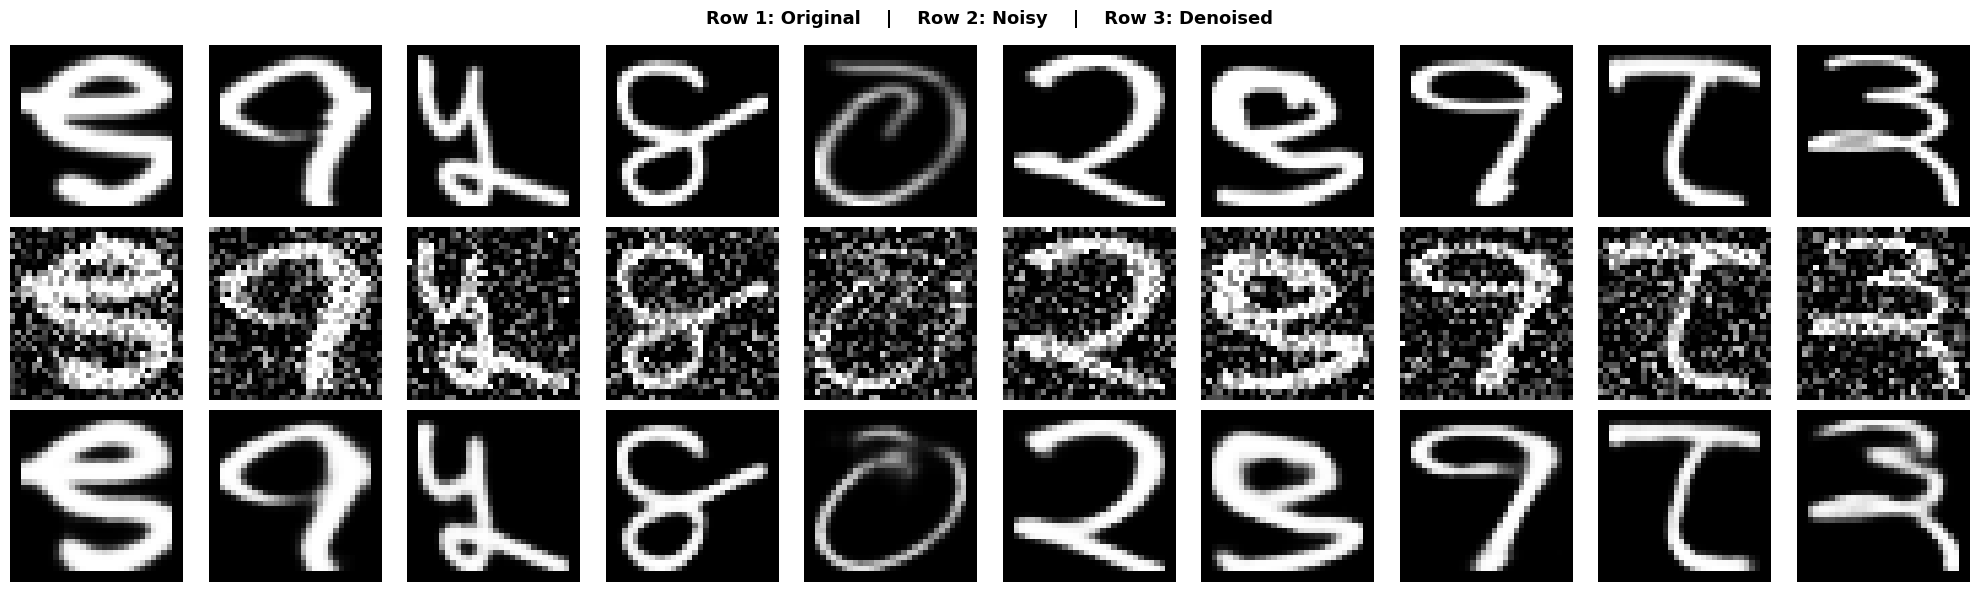

In [63]:
n = 10
fig, axes = plt.subplots(3, n, figsize=(20, 6))
fig.suptitle('Row 1: Original    |    Row 2: Noisy    |    Row 3: Denoised',
             fontsize=13, fontweight='bold')

row_labels = ['Original', 'Noisy', 'Denoised']
rows = [x_val, x_val_noisy, x_denoised]

for row_idx, (row_label, row_data) in enumerate(zip(row_labels, rows)):
    for col_idx in range(n):
        ax = axes[row_idx, col_idx]
        ax.imshow(row_data[col_idx].squeeze(), cmap='gray', vmin=0, vmax=1)
        ax.axis('off')
    axes[row_idx, 0].set_ylabel(row_label, fontsize=11, rotation=90, labelpad=40)

plt.tight_layout()
plt.show()

In [64]:
def compute_psnr(clean, reconstructed):
    mse = np.mean((clean - reconstructed) ** 2)
    if mse == 0:
        return float('inf')
    return 10 * np.log10(1.0 / mse)

mse_noisy    = np.mean((x_val - x_val_noisy) ** 2)
mse_denoised = np.mean((x_val - x_denoised)  ** 2)
psnr_noisy    = compute_psnr(x_val, x_val_noisy)
psnr_denoised = compute_psnr(x_val, x_denoised)

print(f"{'Metric':<22} {'Noisy Input':>14} {'Denoised Output':>16}")
print("-" * 54)
print(f"{'MSE':<22} {mse_noisy:>14.5f} {mse_denoised:>16.5f}")
print(f"{'PSNR (dB)':<22} {psnr_noisy:>14.2f} {psnr_denoised:>16.2f}")
print(f"\nPSNR improvement: +{psnr_denoised - psnr_noisy:.2f} dB")

Metric                    Noisy Input  Denoised Output
------------------------------------------------------
MSE                           0.06359          0.00996
PSNR (dB)                       11.97            20.02

PSNR improvement: +8.05 dB


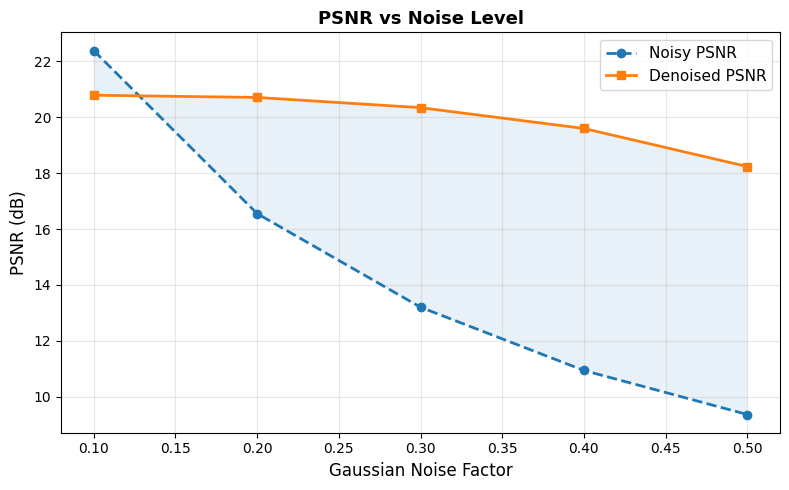

In [65]:
noise_levels  = [0.1, 0.2, 0.3, 0.4, 0.5]
psnr_noisy_list    = []
psnr_denoised_list = []

for nf in noise_levels:
    x_v_n = add_gaussian_noise(x_val, nf)
    x_v_d = autoencoder.predict(x_v_n, batch_size=64, verbose=0)
    psnr_noisy_list.append(compute_psnr(x_val, x_v_n))
    psnr_denoised_list.append(compute_psnr(x_val, x_v_d))

plt.figure(figsize=(8, 5))
plt.plot(noise_levels, psnr_noisy_list,    'o--', label='Noisy PSNR',    linewidth=2)
plt.plot(noise_levels, psnr_denoised_list, 's-',  label='Denoised PSNR', linewidth=2)
plt.fill_between(noise_levels, psnr_noisy_list, psnr_denoised_list, alpha=0.1)
plt.xlabel('Gaussian Noise Factor', fontsize=12)
plt.ylabel('PSNR (dB)', fontsize=12)
plt.title('PSNR vs Noise Level', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Epoch 1/30
266/266 ━━━━━━━━━━━━━━━━━━━━ 125s 453ms/step - loss: 0.3681 - mae: 0.2077 - val_loss: 0.2344 - val_mae: 0.1128
Epoch 2/30
266/266 ━━━━━━━━━━━━━━━━━━━━ 119s 448ms/step - loss: 0.2022 - mae: 0.0887 - val_loss: 0.1805 - val_mae: 0.0736
Epoch 3/30
266/266 ━━━━━━━━━━━━━━━━━━━━ 117s 440ms/step - loss: 0.1707 - mae: 0.0658 - val_loss: 0.1639 - val_mae: 0.0611
Epoch 4/30
266/266 ━━━━━━━━━━━━━━━━━━━━ 140s 434ms/step - loss: 0.1581 - mae: 0.0566 - val_loss: 0.1574 - val_mae: 0.0560
Epoch 5/30
266/266 ━━━━━━━━━━━━━━━━━━━━ 146s 450ms/step - loss: 0.1508 - mae: 0.0512 - val_loss: 0.1491 - val_mae: 0.0500
Epoch 6/30
266/266 ━━━━━━━━━━━━━━━━━━━━ 116s 438ms/step - loss: 0.1460 - mae: 0.0476 - val_loss: 0.1459 - val_mae: 0.0474
Epoch 7/30
266/266 ━━━━━━━━━━━━━━━━━━━━ 123s 463ms/step - loss: 0.1434 - mae: 0.0456 - val_loss: 0.1439 - val_mae: 0.0454
Epoch 8/30
266/266 ━━━━━━━━━━━━━━━━━━━━ 123s 462ms/step - loss: 0.1408 - mae: 0.0437 - val_loss: 0.1430 - val_mae: 0.0448
Epoch 9/30
266/266 ━━━━━

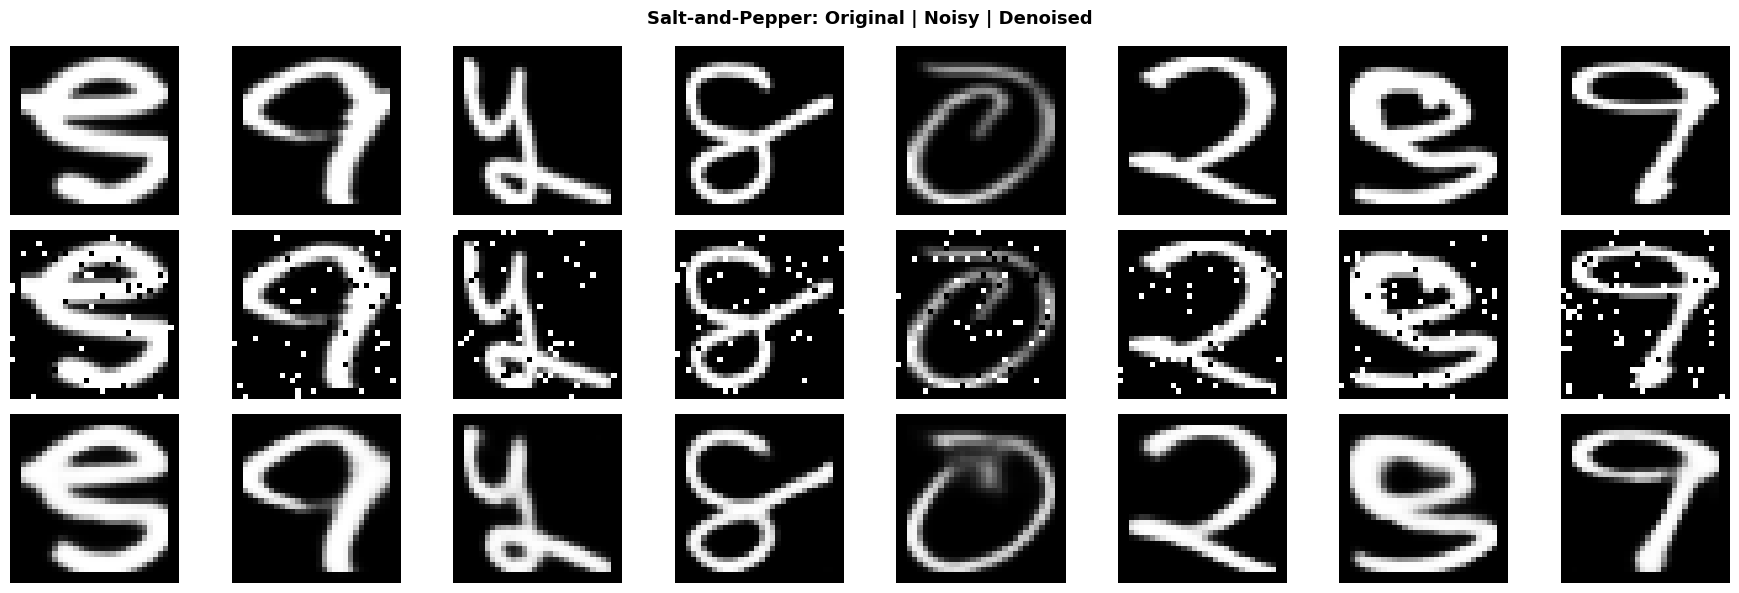

In [66]:
x_train_sp = add_salt_pepper_noise(x_train, prob=0.08)
x_val_sp   = add_salt_pepper_noise(x_val,   prob=0.08)

ae_sp = build_autoencoder()
ae_sp.compile(optimizer='adam', loss='binary_crossentropy', metrics=['mae'])

history_sp = ae_sp.fit(
    x_train_sp, x_train,
    epochs=30,
    batch_size=64,
    shuffle=True,
    validation_data=(x_val_sp, x_val),
    callbacks=[EarlyStopping(patience=6, restore_best_weights=True, verbose=1)],
    verbose=1
)

x_den_sp = ae_sp.predict(x_val_sp, batch_size=64, verbose=0)

print(f"\nSalt-and-Pepper PSNR — Noisy   : {compute_psnr(x_val, x_val_sp):.2f} dB")
print(f"Salt-and-Pepper PSNR — Denoised: {compute_psnr(x_val, x_den_sp):.2f} dB")

# Visualise salt-and-pepper results
n = 8
fig, axes = plt.subplots(3, n, figsize=(18, 6))
fig.suptitle('Salt-and-Pepper: Original | Noisy | Denoised',
             fontsize=13, fontweight='bold')
for i in range(n):
    axes[0, i].imshow(x_val[i].squeeze(),    cmap='gray', vmin=0, vmax=1)
    axes[1, i].imshow(x_val_sp[i].squeeze(), cmap='gray', vmin=0, vmax=1)
    axes[2, i].imshow(x_den_sp[i].squeeze(), cmap='gray', vmin=0, vmax=1)
    for r in range(3):
        axes[r, i].axis('off')
for r, lbl in enumerate(['Original', 'Noisy', 'Denoised']):
    axes[r, 0].set_ylabel(lbl, fontsize=11)
plt.tight_layout()
plt.show()